# Stage 2 — complete experiment comparison

Scan the complete Stage 2 artifact tree, exclude incomplete LOSO runs, export a compact thesis-ready table, show one matched representative comparison, and generate the Section 4.2.3 subject-level heterogeneous-benefit figure.


In [1]:
from pathlib import Path
import json, os, subprocess, sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
SRC_DIR = ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))
SUBPROCESS_ENV = os.environ.copy()
SUBPROCESS_ENV['PYTHONPATH'] = str(SRC_DIR) + os.pathsep + SUBPROCESS_ENV.get('PYTHONPATH', '')

ARTIFACTS = Path('artifacts/stage2')
OUTPUT = Path('results/tables/stage2/fusion_comparison')
EXPECTED_SUBJECTS = 154
REPRESENTATIVE_METHOD = 'residual'   # concatenation, film, or residual
REPRESENTATIVE_STRATEGY = 'finetune' # finetune or scratch
HETEROGENEITY_METHOD = 'residual'    # final Section 4.2.3 method
HETEROGENEITY_FALLBACK_METHOD = 'concatenation'  # whole-matrix preview only

ARTIFACTS, REPRESENTATIVE_METHOD, REPRESENTATIVE_STRATEGY, HETEROGENEITY_METHOD


(PosixPath('artifacts/stage2'), 'residual', 'finetune', 'residual')

## Build the complete comparison

Every completed configuration is identified by feature source, fusion method, training strategy, and target. The primary paired quantity is ΔRMSE = experiment RMSE − DRS-only RMSE for the same held-out subject; negative values favor the experiment. Runs with fewer than `EXPECTED_SUBJECTS` unique folds are reported and skipped.


In [2]:
command = [
    sys.executable, '-m', 'subject_nirs.stage2.comparison',
    '--root', str(ARTIFACTS),
    '--output-dir', str(OUTPUT),
    '--expected-subjects', str(EXPECTED_SUBJECTS),
    '--representative-method', REPRESENTATIVE_METHOD,
    '--representative-strategy', REPRESENTATIVE_STRATEGY,
    '--heterogeneity-method', HETEROGENEITY_METHOD,
    '--no-pdf',
]
if HETEROGENEITY_FALLBACK_METHOD is not None:
    command += ['--heterogeneity-fallback-method', HETEROGENEITY_FALLBACK_METHOD]
subprocess.run(command, cwd=ROOT, env=SUBPROCESS_ENV, check=True)


Loaded DRS only               target=hc   folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/baseline/hc
Loaded DRS only               target=sto2 folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/baseline/sto2
Loaded DTOF latent | Concatenation | Fine-tune target=hc   folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/concatenation/finetune/dtof/hc
Loaded DTOF latent | Concatenation | Fine-tune target=sto2 folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/concatenation/finetune/dtof/sto2
Loaded Layer thickness | Concatenation | Fine-tune target=hc   folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/concatenation/finetune/metadata/hc
Loaded Layer thickness | Concatenation | Fine-tune target=sto2 folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/concatenation/finetune/me


Experiment summary (median RMSE / median |Bias|):
   tHb | DRS only                 | n=154 | RMSE=14.034 | |Bias|=8.9657
   tHb | DTOF latent | Concatenation | Fine-tune | n=154 | RMSE=12.782 | |Bias|=7.5754
   tHb | DTOF latent | Concatenation | Scratch | n=154 | RMSE=14.682 | |Bias|=7.8145
   tHb | DTOF latent | FiLM | Fine-tune | n=154 | RMSE=12.922 | |Bias|=8.3465
   tHb | DTOF latent | FiLM | Scratch | n=154 | RMSE=14.254 | |Bias|=8.2877
   tHb | DTOF latent | Residual | Fine-tune | n=154 | RMSE=12.493 | |Bias|=7.4742
   tHb | DTOF latent | Residual | Scratch | n=154 | RMSE=14.113 | |Bias|=7.4496
   tHb | Layer thickness | Concatenation | Fine-tune | n=154 | RMSE=12.571 | |Bias|=7.2169
   tHb | Layer thickness | Concatenation | Scratch | n=154 | RMSE=12.684 | |Bias|=7.5411
   tHb | Layer thickness | FiLM | Fine-tune | n=154 | RMSE=12.577 | |Bias|=7.6112
  StO₂ | DRS only                 | n=154 | RMSE=0.045467 | |Bias|=0.026332
  StO₂ | DTOF latent | Concatenation | Fine-tune | 

CompletedProcess(args=['/home/md703/.conda/envs/yc_ae/bin/python', '-m', 'subject_nirs.stage2.comparison', '--root', 'artifacts/stage2', '--output-dir', 'results/tables/stage2/fusion_comparison', '--expected-subjects', '154', '--representative-method', 'residual', '--representative-strategy', 'finetune', '--heterogeneity-method', 'residual', '--no-pdf', '--heterogeneity-fallback-method', 'concatenation'], returncode=0)

## Display the thesis-ready table and representative figure

`final_experiment_table.csv` retains numeric columns for later analysis. The formatted CSV is convenient for direct thesis-table review.


,target,feature_source,fusion_method,training_strategy,experiment,n_subjects,"RMSE median [Q1, Q3]","Bias median [Q1, Q3]","paired ΔRMSE median [Q1, Q3]",improved subjects (%),paired rank-biserial,Holm-adjusted p
0,hc,baseline,none,scratch,DRS only,154,"14.03 [10.52, 17.89]","1.071 [-9.824, 8.306]",—,—,—,—
1,hc,latent,concatenation,scratch,DTOF latent | Concatenation | Scratch,154,"14.68 [10.66, 17.82]","-1.946 [-8.873, 6.436]","+0.1192 [-3.55, +3.683]",48.7,-0.031,1
2,hc,latent,concatenation,finetune,DTOF latent | Concatenation | Fine-tune,154,"12.78 [9.916, 17.13]","-0.5122 [-7.35, 7.703]","-0.6468 [-3.016, +0.8654]",63.0,+0.342,0.0014
3,hc,latent,film,scratch,DTOF latent | FiLM | Scratch,154,"14.25 [11.28, 17.87]","-0.9799 [-8.873, 6.548]","+0.06014 [-3.932, +3.68]",48.1,-0.017,1
4,hc,latent,film,finetune,DTOF latent | FiLM | Fine-tune,154,"12.92 [9.77, 17.43]","-0.4621 [-8.234, 8.344]","-0.7264 [-2.829, +0.8518]",62.3,+0.304,0.00459
5,hc,latent,residual,scratch,DTOF latent | Residual | Scratch,154,"14.11 [11.65, 17.72]","-0.5548 [-8.565, 6.969]","+0.02557 [-3.685, +3.765]",50.0,-0.016,1
6,hc,latent,residual,finetune,DTOF latent | Residual | Fine-tune,154,"12.49 [9.851, 17.16]","-0.363 [-7.559, 7.375]","-0.7652 [-3.001, +0.6986]",63.0,+0.367,0.000536
7,hc,metadata,concatenation,scratch,Layer thickness | Concatenation | Scratch,154,"12.68 [9.901, 15.7]","-0.3068 [-7.513, 7.341]","-0.7298 [-4.272, +1.713]",59.7,+0.308,0.00459
8,hc,metadata,concatenation,finetune,Layer thickness | Concatenation | Fine-tune,154,"12.57 [10.1, 15.48]","-0.8381 [-8.063, 6.251]","-1.251 [-3.563, +0.4259]",68.8,+0.499,6.91e-07
9,hc,metadata,film,finetune,Layer thickness | FiLM | Fine-tune,154,"12.58 [10.05, 15.51]","-0.636 [-7.761, 7.126]","-0.89 [-3.345, +0.2664]",71.4,+0.493,8.96e-07


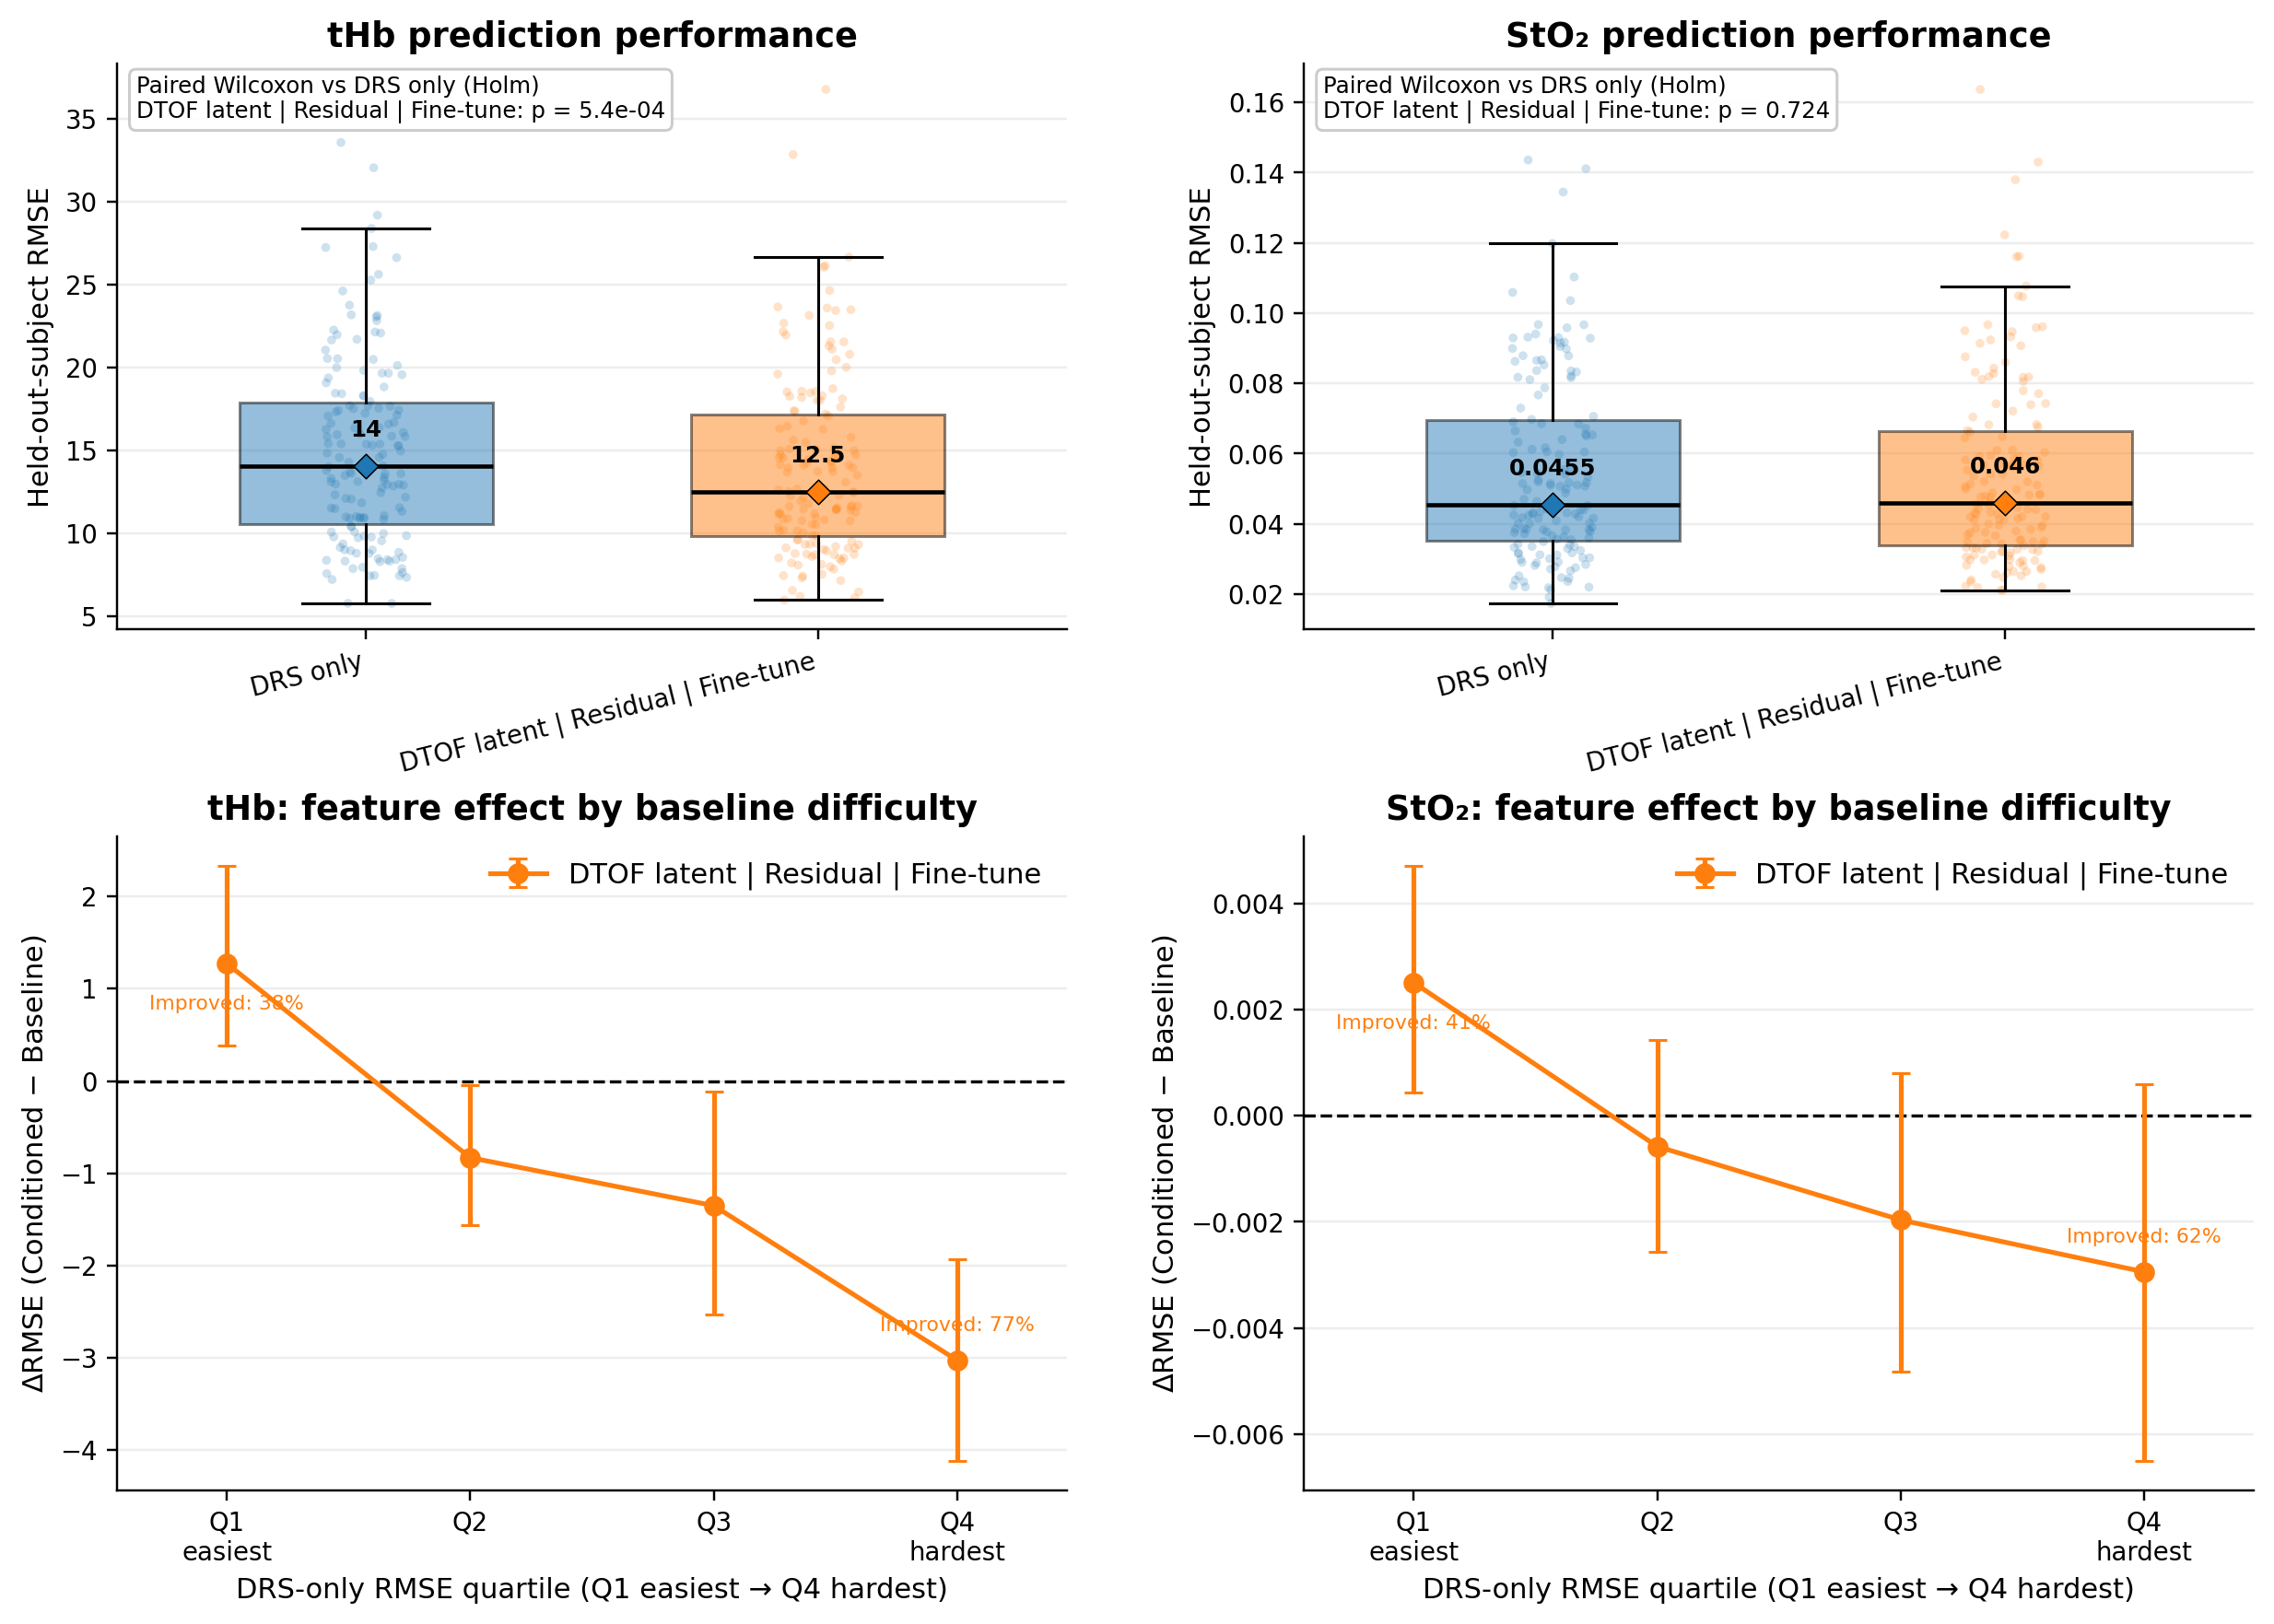

,target,feature_source,fusion_method,training_strategy,experiment,n_subjects,rmse_median,rmse_q1,rmse_q3,bias_median,bias_q1,bias_q3,n_paired_subjects,delta_rmse_median,delta_rmse_q1,delta_rmse_q3,improved_subjects_pct,paired_rank_biserial,wilcoxon_p,wilcoxon_p_holm
0,hc,baseline,none,scratch,DRS only,154,14.033874,10.521772,17.889792,1.071402,-9.824305,8.305751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hc,latent,concatenation,scratch,DTOF latent | Concatenation | Scratch,154,14.682302,10.664454,17.824935,-1.946035,-8.873470,6.435624,154.0,0.119215,-3.550199,3.683188,48.701299,-0.030750,7.406397e-01,1.000000e+00
2,hc,latent,concatenation,finetune,DTOF latent | Concatenation | Fine-tune,154,12.782431,9.915918,17.133410,-0.512225,-7.350297,7.702928,154.0,-0.646770,-3.015849,0.865395,62.987013,0.341935,2.325454e-04,1.395273e-03
3,hc,latent,film,scratch,DTOF latent | FiLM | Scratch,154,14.254025,11.275131,17.871347,-0.979889,-8.873167,6.548067,154.0,0.060141,-3.931794,3.680245,48.051948,-0.016674,8.575585e-01,1.000000e+00
4,hc,latent,film,finetune,DTOF latent | FiLM | Fine-tune,154,12.922002,9.769799,17.431146,-0.462089,-8.233754,8.344159,154.0,-0.726385,-2.828506,0.851774,62.337662,0.303561,1.084358e-03,4.589169e-03
5,hc,latent,residual,scratch,DTOF latent | Residual | Scratch,154,14.112516,11.645718,17.718287,-0.554815,-8.564817,6.969272,154.0,0.025566,-3.685359,3.764796,50.000000,-0.016339,8.603919e-01,1.000000e+00
6,hc,latent,residual,finetune,DTOF latent | Residual | Fine-tune,154,12.492620,9.851041,17.161531,-0.362965,-7.558792,7.375318,154.0,-0.765199,-3.001275,0.698623,62.987013,0.367407,7.655423e-05,5.358796e-04
7,hc,metadata,concatenation,scratch,Layer thickness | Concatenation | Scratch,154,12.684021,9.901166,15.703347,-0.306837,-7.512717,7.341361,154.0,-0.729839,-4.271741,1.713163,59.740260,0.307918,9.178338e-04,4.589169e-03
8,hc,metadata,concatenation,finetune,Layer thickness | Concatenation | Fine-tune,154,12.571402,10.102096,15.476245,-0.838095,-8.063185,6.250682,154.0,-1.251029,-3.562943,0.425912,68.831169,0.499288,7.676651e-08,6.908986e-07
9,hc,metadata,film,finetune,Layer thickness | FiLM | Fine-tune,154,12.576810,10.051442,15.513262,-0.635983,-7.760641,7.126309,154.0,-0.890016,-3.344651,0.266449,71.428571,0.492920,1.120436e-07,8.963488e-07


In [3]:
numeric_table = pd.read_csv(OUTPUT / 'final_experiment_table.csv')
formatted_table = pd.read_csv(OUTPUT / 'final_experiment_table_formatted.csv')
display(formatted_table)
display(Image(filename=str(OUTPUT / 'representative_loso_comparison.png'), width=1300))

# Keep the numeric table available for sorting/filtering in later cells.
numeric_table


## Section 4.2.3 — subject-level heterogeneous benefit

The four panels fix one fusion operator and compare DTOF descriptor versus layer thickness across scratch and DRS-only-checkpoint fine-tuning. Columns are tHb and StO₂; rows are training strategies. Q1–Q4 are assigned once per target from DRS-only held-out-subject RMSE, and negative ΔRMSE indicates improvement.

If the requested gated-residual matrix is incomplete, the notebook uses one complete concatenation matrix for a clearly labelled layout preview. It never mixes operators across missing cells.


{'requested_method': 'residual',
 'fallback_method': 'concatenation',
 'selected_method': 'concatenation',
 'is_preview': True,
 'requested_method_missing_cells': ['hc/scratch/metadata',
  'hc/finetune/metadata',
  'sto2/scratch/latent',
  'sto2/scratch/metadata',
  'sto2/finetune/metadata'],
 'generated': True,
 'image': 'heterogeneous_benefit_concatenation_preview_for_residual.png',
 'summary': 'heterogeneous_benefit_concatenation_preview_for_residual.csv'}

**Preview only:** the requested gated-residual matrix is incomplete; the complete concatenation matrix is used for layout verification.

,target,fusion_method,training_strategy,feature_source,difficulty_quartile,n_subjects,delta_RMSE_median,delta_RMSE_Q1,delta_RMSE_Q3,improved_subjects_pct
0,hc,concatenation,scratch,latent,Q1,39,2.492949,0.119215,6.513968,20.512821
1,hc,concatenation,scratch,latent,Q2,38,2.359103,-2.001602,4.776202,31.578947
2,hc,concatenation,scratch,latent,Q3,38,-1.585204,-3.542065,2.467228,65.789474
3,hc,concatenation,scratch,latent,Q4,39,-4.868504,-8.051018,-0.949499,76.923077
4,hc,concatenation,scratch,metadata,Q1,39,1.275733,-0.253163,2.678636,30.769231
5,hc,concatenation,scratch,metadata,Q2,38,-0.739102,-2.389482,1.910927,60.526316
6,hc,concatenation,scratch,metadata,Q3,38,-1.290735,-5.085629,1.075373,63.157895
7,hc,concatenation,scratch,metadata,Q4,39,-5.511246,-9.162093,-1.170260,84.615385
8,hc,concatenation,finetune,latent,Q1,39,0.560940,-0.402192,2.479619,43.589744
9,hc,concatenation,finetune,latent,Q2,38,-0.691416,-2.862416,0.887595,57.894737


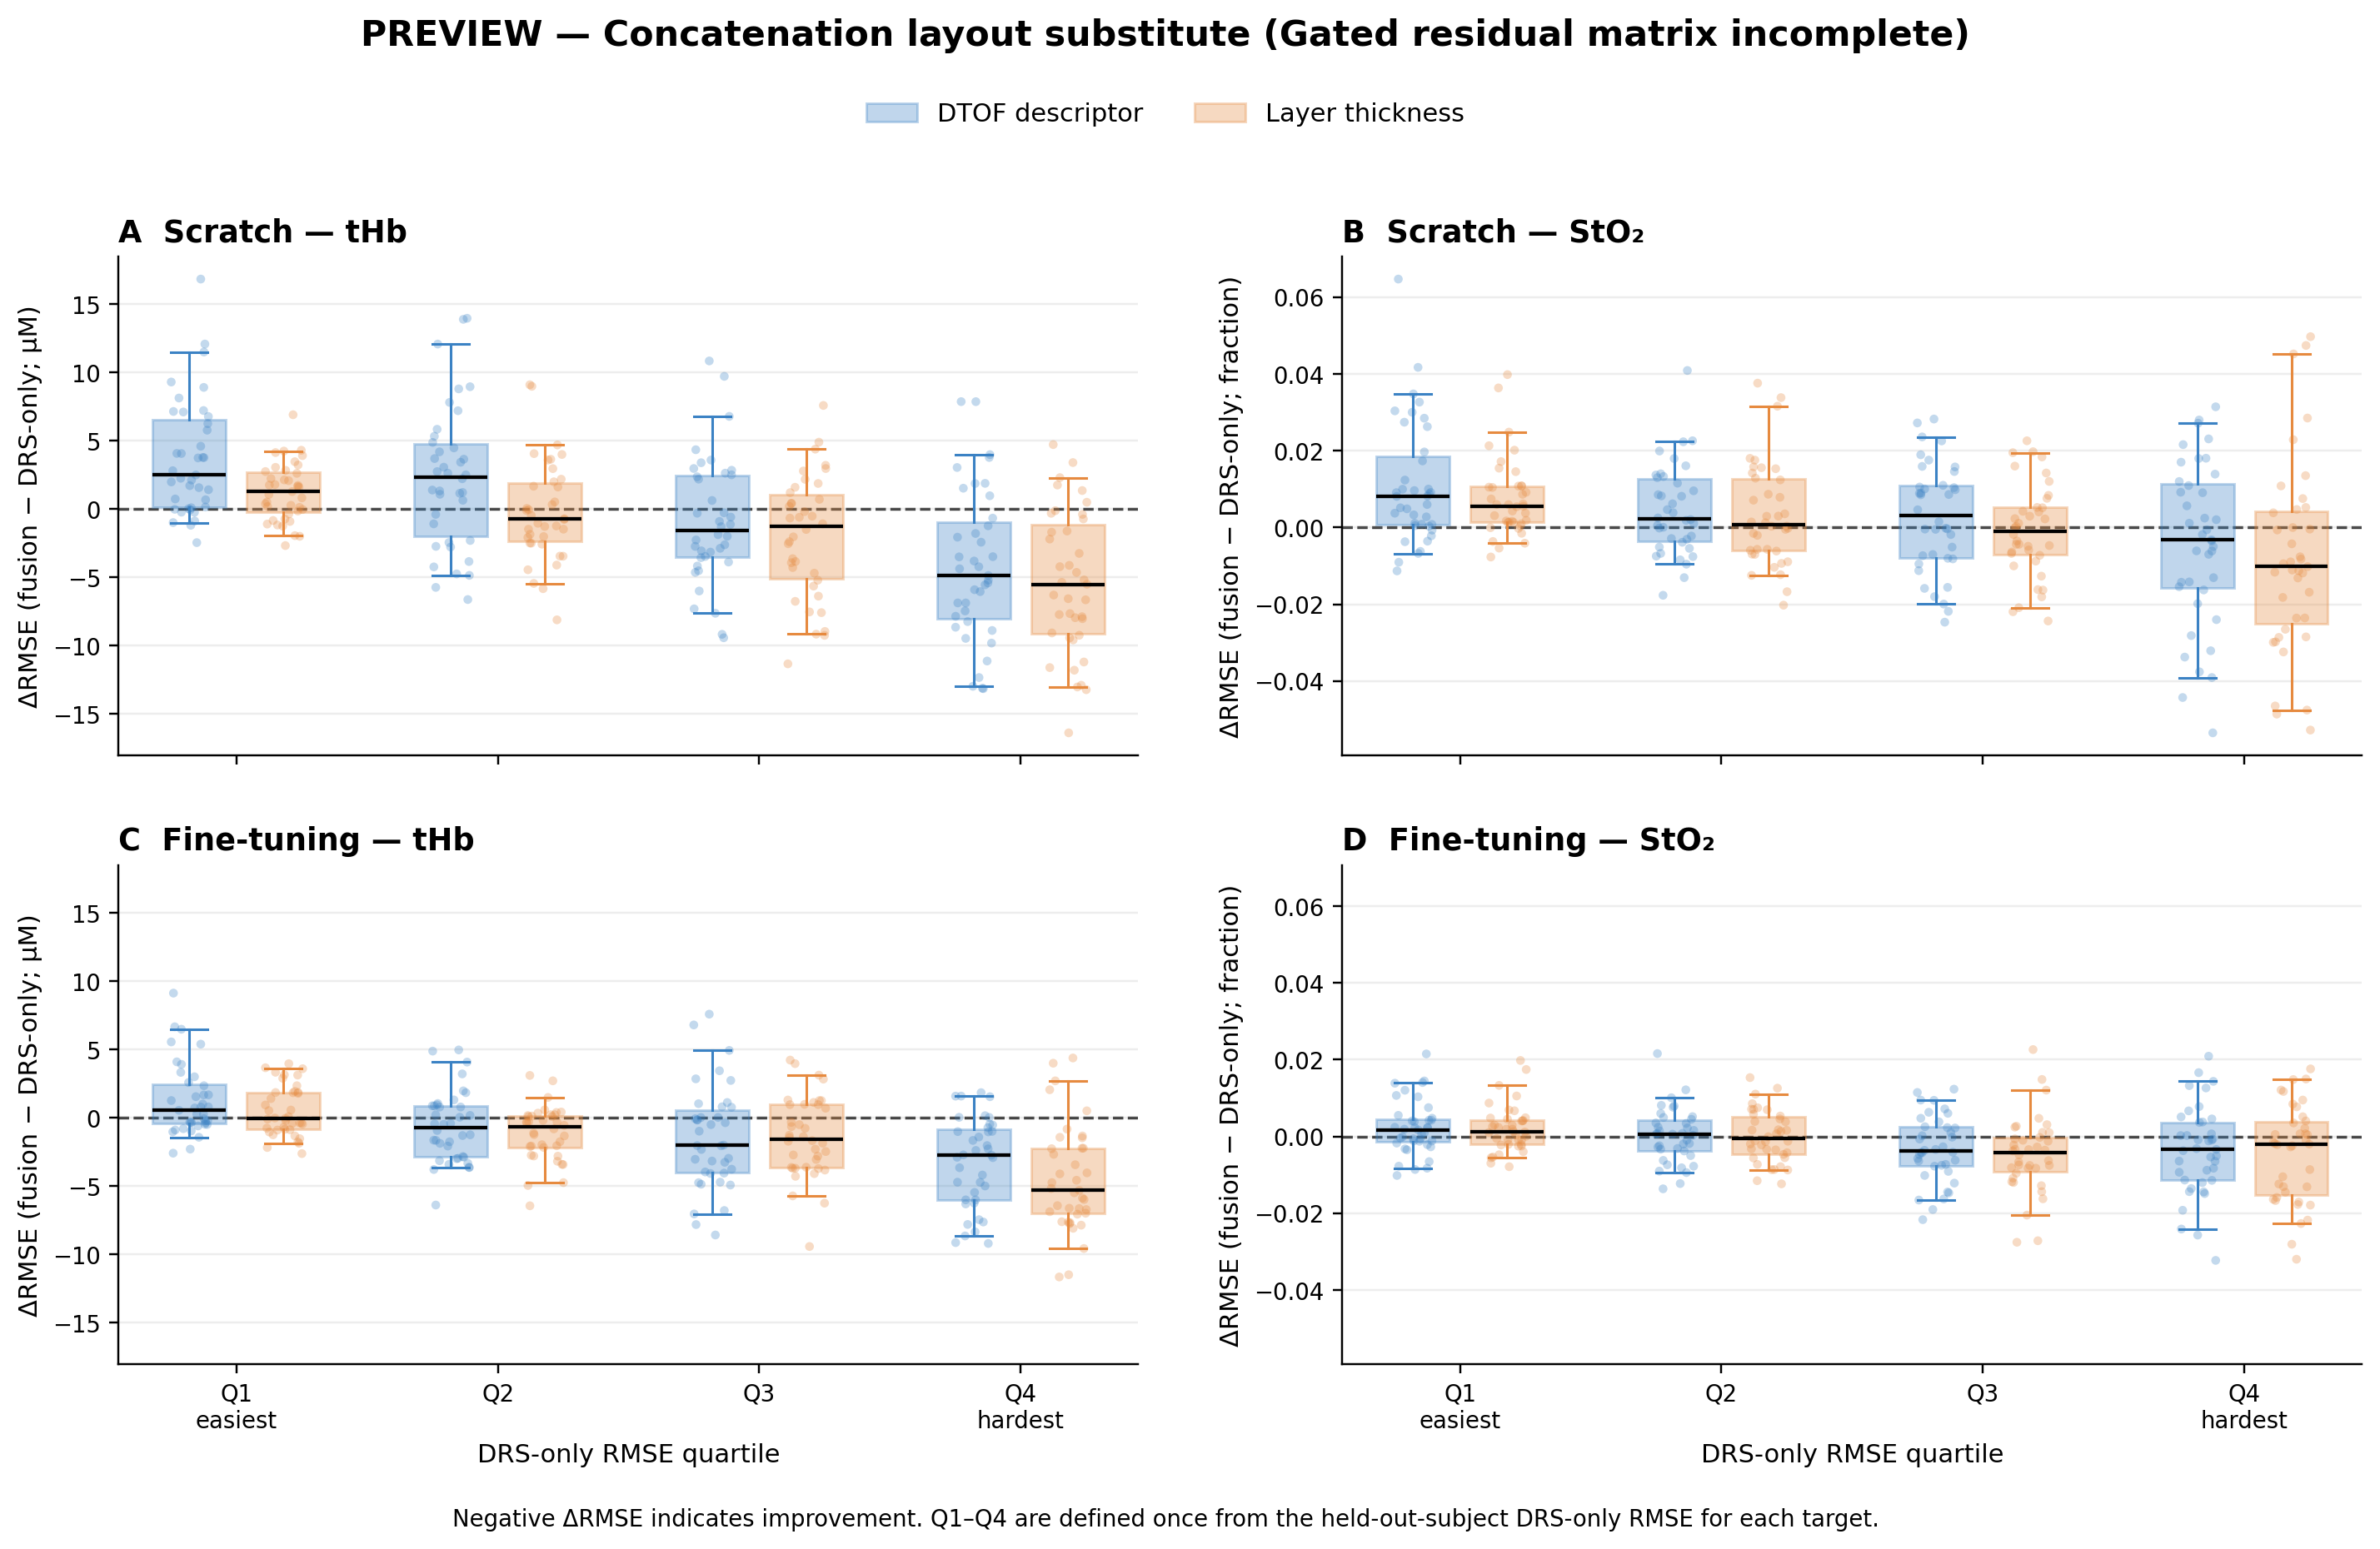

In [4]:
manifest_path = OUTPUT / 'heterogeneous_benefit_manifest.json'
heterogeneity_manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
display(heterogeneity_manifest)

if heterogeneity_manifest['generated']:
    if heterogeneity_manifest['is_preview']:
        display(Markdown(
            '**Preview only:** the requested gated-residual matrix is incomplete; '
            'the complete concatenation matrix is used for layout verification.'
        ))
    heterogeneity_table = pd.read_csv(OUTPUT / heterogeneity_manifest['summary'])
    display(heterogeneity_table)
    display(Image(filename=str(OUTPUT / heterogeneity_manifest['image']), width=1400))
else:
    display(Markdown('**Figure not generated:** no complete requested or fallback matrix.'))
